# Set up workspace

In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
import icechunk
import zarr
from icechunk.xarray import to_icechunk

zarr.config.set({"async.concurrency": 128})

In [3]:
from srm import run_bcsd

# Run through clunky BCSD workflow

In [4]:
RUN_PARAMETERS = {
    "gcm": "CESM2-WACCM",
    "train_period_start": 1978,
    "train_period_end": 2014,
    "predict_period_start": 2015,
    "predict_period_end": 2100,
    "var_name": "tas",
}

In [5]:
# Spatial information if subsetting run to a single country

df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

subset_bounds = [lat_min, lat_max, lon_min, lon_max]

In [6]:
# Rechunking in between steps
dict_all = run_bcsd.run_bcsd(
    gcm=RUN_PARAMETERS["gcm"],
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    var_name=RUN_PARAMETERS["var_name"],
    verbose=True,
    rechunk_workflow=True,
    subset_bounds=subset_bounds,
)

Loaded data: 1.12 seconds
Subset time: 0.00 seconds
Rechunked obs to full space: 5.45 seconds
Interpolated obs to coarse grid: 59.88 seconds
Rechunked all to full time: 1.33 seconds
Detrended data: 12.99 seconds
Quantile mapped historical: 16.21 seconds
Quantile mapped future: 23.76 seconds
Added back trend: 0.02 seconds
Rechunked all to full space: 0.25 seconds
Downscaled historical: 8.26 seconds
Downscaled future: 9.85 seconds


# Save results

In [ ]:
# Option 1: save as zarr
for key in ["model_hist_debiased_downscaled", "scenario_debiased_downscaled"]:
    print(key)
    s3_path = "s3://carbonplan-scratch/srm-scratch/v0.3_global/" + key + ".zarr"
    ds = dict_all[key].to_dataset(name=RUN_PARAMETERS["var_name"])
    ds.to_zarr(s3_path, encoding={var: {"shards": None} for var in ds.data_vars}, mode="w")

In [ ]:
# Option 2: save as icechunk. Example:
for key in ["model_hist_debiased_downscaled", "scenario_debiased_downscaled"]:
    storage = icechunk.s3_storage(
        bucket="carbonplan-scratch",
        prefix="srm-scratch/v0.3_global/" + key + ".icechunk",
        from_env=True,
    )
    repo = icechunk.Repository.create(storage)

    session = repo.writable_session("main")

    to_icechunk(ds, session)
    session.commit("write data")

# Look at results

In [7]:
dict_all["model_hist_debiased_downscaled"] = (
    dict_all["model_hist_debiased_downscaled"].chunk(time=1000, lat=7, lon=7).compute()
)

In [8]:
dict_all["scenario_debiased_downscaled"] = (
    dict_all["scenario_debiased_downscaled"].chunk(time=1000, lat=7, lon=7).compute()
)

In [9]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

/tmp/ipykernel_2761/1595652233.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
/tmp/ipykernel_2761/1595652233.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),


1


Text(0.5, 1.0, 'Raw coarse model data')

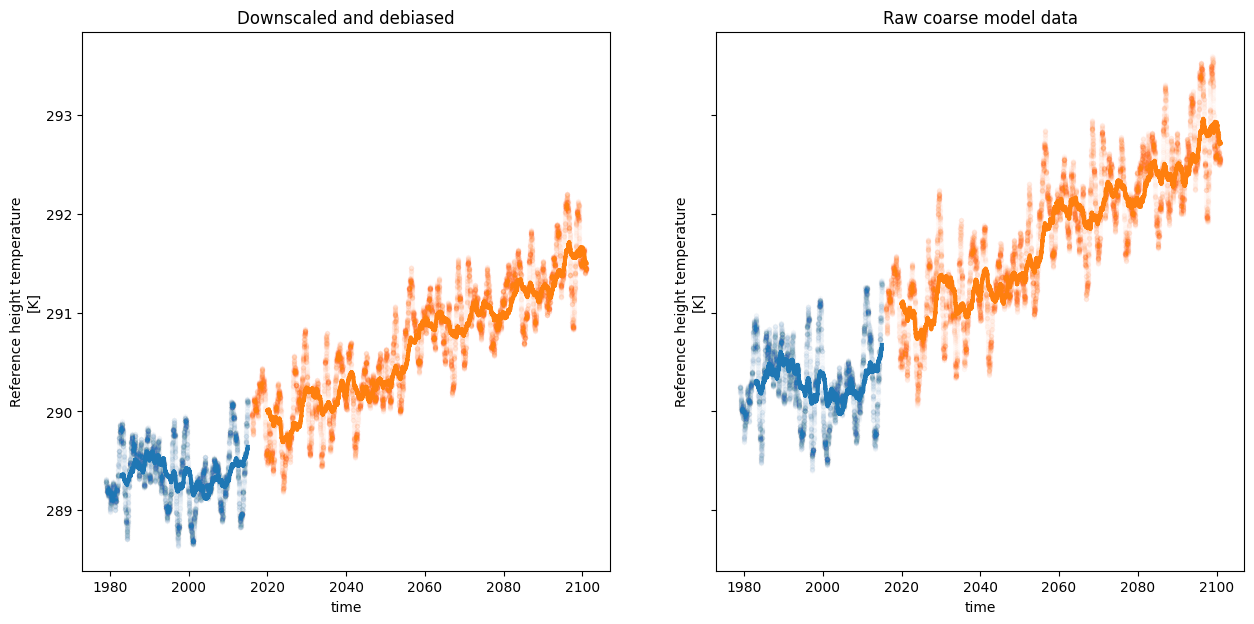

In [10]:
[fig, ax] = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(15, 7))

plt.subplot(1, 2, 1)
dict_all["model_hist_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C0")
dict_all["model_hist_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365 * 5).mean().plot(color="C0", linewidth=3)

dict_all["scenario_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C1")
dict_all["scenario_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365 * 5).mean().plot(color="C1", linewidth=3)
ax[0].set_title("Downscaled and debiased")

plt.subplot(1, 2, 2)
dict_all["model_hist"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365
).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C0")
dict_all["model_hist"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365 * 5
).mean().plot(color="C0", linewidth=3)

dict_all["model_scenario"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365
).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C1")
dict_all["model_scenario"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365 * 5
).mean().plot(color="C1", linewidth=3)
ax[1].set_title("Raw coarse model data")